In [44]:
%load_ext autoreload
%autoreload 2

import argparse
from dataclasses import dataclass
from pathlib import Path

import hist
import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

from analysis.utils.datasets import CNNProjectionDataset
from analysis.utils.geometry import Geometry, get_rebinned_geometry
from analysis.utils.networks import ClassifierProjectionCNN, RegressionCNN
from analysis.utils.plot_utils import setup
from analysis.utils.torch_data_utils import evaluate_model
from analysis.utils.torch_utils import (
    get_device,
    load_weights,
    show_model,
    train,
)
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_figures_path,
    get_npy_path,
    get_parquet_path,
    get_torch_path,
    get_weights_path,
)
from analysis.utils.validation_utils import (
    get_accuracy_dict,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_probabilities,
    plot_roc_curve,
    plot_training_metrics,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
setup()

In [4]:
truth_df = pd.read_parquet(get_torch_path() / "cnn_projection_truth.parq")

In [7]:
feature_dim: int = 128
# geometry_label = "cnn_projection_200um_bins_10000_10003"
# geometry_label = "theta_100mrad_ratio_10"
geometry_label = "./"
torch_path = get_torch_path() / geometry_label / "cnn.pt"
weights_path = get_weights_path() / geometry_label / "vx_regression"
figures_path = get_figures_path() / geometry_label / "vx_regression"

dataset = torch.load(torch_path, weights_only=False, map_location="cpu")

test_dataset = dataset  # Use full dataset for testing
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True)

device = get_device()

model = RegressionCNN(feature_dim=feature_dim)
model = model.to(device)

load_weights(model, device, weights_path / "model_weights.pth")

Using device: cpu


In [10]:
model.eval()
y_true_list = []
y_pred_list = []

with torch.no_grad():
    for data, target in test_loader:
        if isinstance(data, (tuple, list)):
            data = tuple(d.to(device) for d in data)
        else:
            data = data.to(device)

        target_val = target["delta_vx"].to(device).float()
        output = model(
            data
        ).squeeze()  # Remove extra dimension from (batch, 1) to (batch,)

        y_true_list.extend(target_val.cpu().numpy())
        y_pred_list.extend(output.cpu().numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x164a673b0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

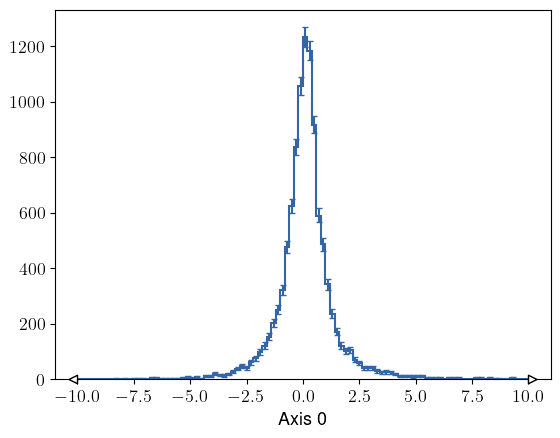

In [45]:
delta_vx = y_pred - y_true

h = hist.Hist(hist.axis.Regular(100, -10, 10))
h.fill(delta_vx)
mplhep.histplot(h)

In [46]:
num_events = len(dataset)
mean_x = np.zeros(num_events)
for i in range(num_events):
    mean_x[i] = dataset[i][1]["vx"] + dataset[i][1]["delta_vx"]

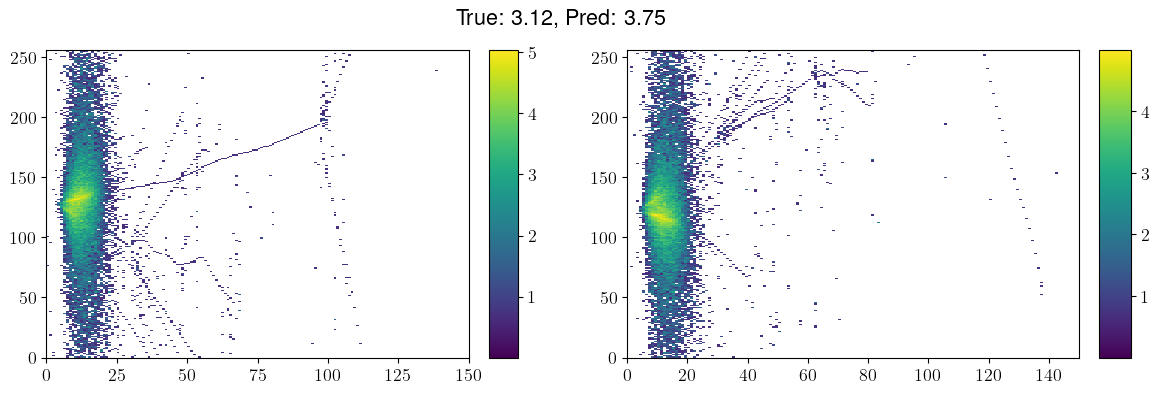

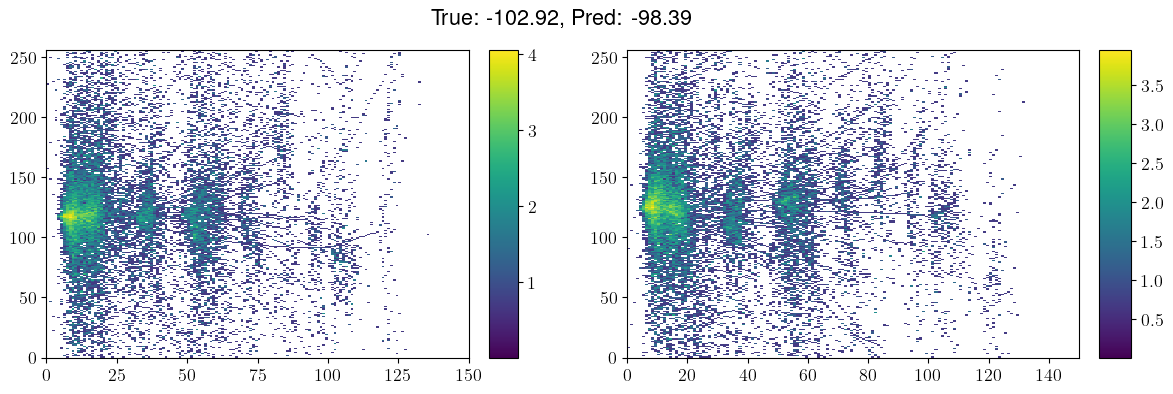

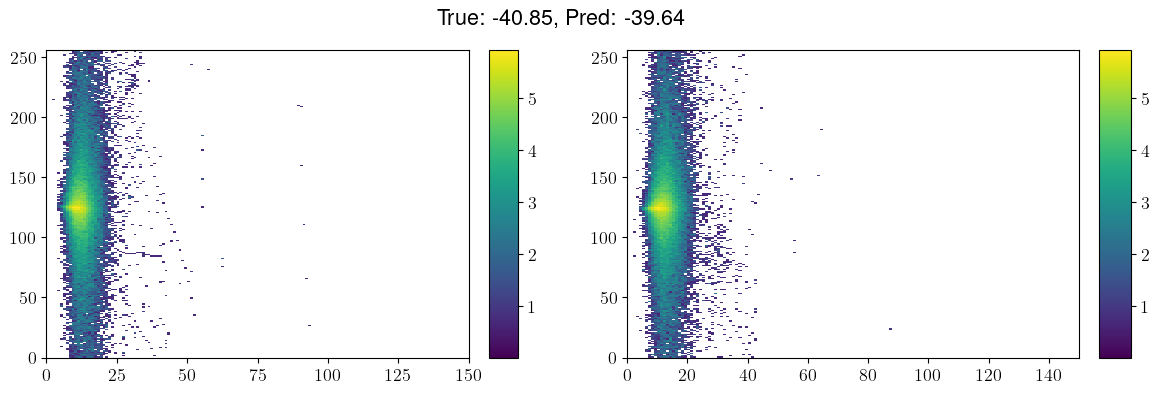

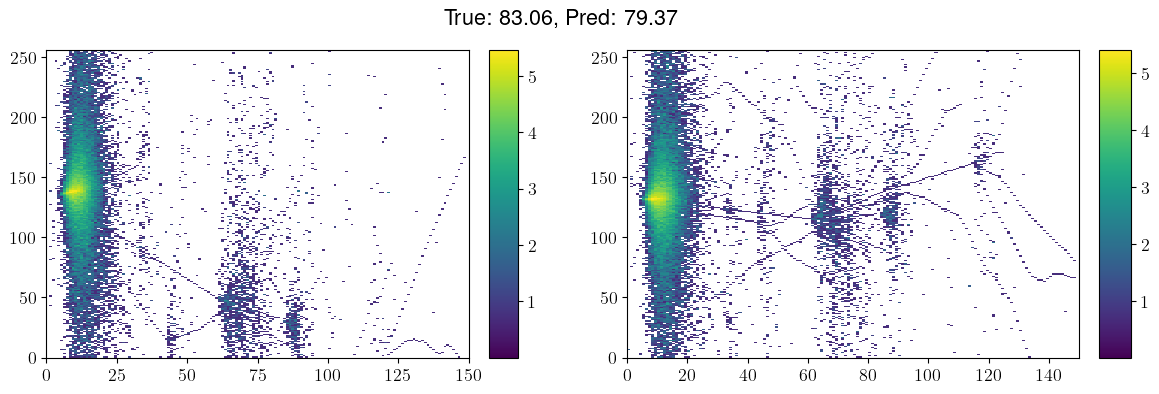

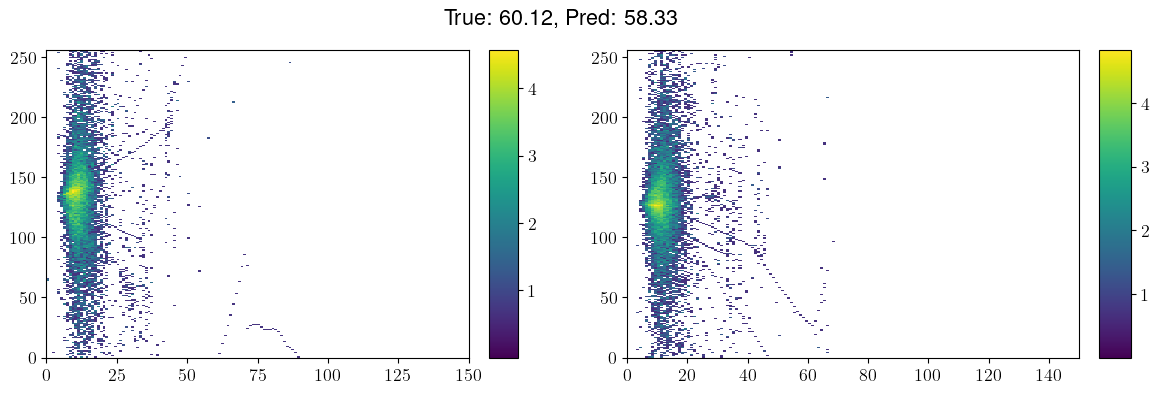

In [60]:
for idx in range(5):
    fig, axs = plt.subplots(1, 2, figsize=(2 * 6, 4))
    (zx, zy), truth = dataset[idx]
    plt.suptitle(
        f"True: {truth_df['vx'].iloc[idx]:.2f}, Pred: {y_pred[idx] + mean_x[idx]:.2f}"
    )
    for i, proj in enumerate([zx, zy]):
        proj = proj.cpu().numpy()[0]
        mplhep.hist2dplot(proj, cmin=1e-3, ax=axs[i])
    plt.show()


In [17]:
dataset[0][1]

{'label': 0,
 'E_nu': np.float32(792630.0),
 'E_lepton': np.float32(541911.06),
 'delta_vx': np.float32(0.28481808),
 'delta_vy': np.float32(1.3112351),
 'vx': np.float32(3.115182),
 'vy': np.float32(-47.711235)}